In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [ ]:
#Key Observations
#Dataset is clean and structured
#Categories and brands are well distributed
#Price and ratings provide strong signals for recommendation
#Tags and descriptions enable content-based recommendation systems

In [2]:
df = pd.read_csv('products.csv')
df.head()

,product_id,product_name,brand,category,sub_category,price,rating,review_count,stock_status,tags,description
0,1,Organic Whole Milk,FreshFarm,Groceries,Dairy,4.99,4.6,320,In Stock,milk|organic|dairy,Fresh organic whole milk sourced from local farms.
1,2,Bluetooth Wireless Headphones,TechNova,Electronics,Audio,59.99,4.4,210,In Stock,audio|wireless|music,High-quality wireless headphones with noise isolation.
2,3,Cotton Casual T-Shirt,UrbanWear,Clothing,Tops,12.99,4.2,150,In Stock,clothing|casual|cotton,Comfortable cotton t-shirt for everyday wear.
3,4,Non-Stick Cooking Pan,HomeEase,Home & Kitchen,Cookware,24.99,4.5,180,In Stock,kitchen|cookware|pan,Durable non-stick pan for easy cooking and cleaning.
4,5,Vitamin C Tablets,PureCare,Personal Care,Supplements,9.99,4.3,95,In Stock,health|vitamin|supplement,Daily vitamin C tablets to support immunity.


In [3]:
#Dataset Overview
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.info()

Shape: (20, 11)

Columns:
['product_id', 'product_name', 'brand', 'category', 'sub_category', 'price', 'rating', 'review_count', 'stock_status', 'tags', 'description']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    20 non-null     int64  
 1   product_name  20 non-null     object 
 2   brand         20 non-null     object 
 3   category      20 non-null     object 
 4   sub_category  20 non-null     object 
 5   price         20 non-null     float64
 6   rating        20 non-null     float64
 7   review_count  20 non-null     int64  
 8   stock_status  20 non-null     object 
 9   tags          20 non-null     object 
 10  description   20 non-null     object 
dtypes: float64(2), int64(2), object(7)
memory usage: 1.8+ KB


In [4]:
#Missing Values Analysis


In [5]:
df.isnull().sum().sort_values(ascending=False)

product_id      0
product_name    0
brand           0
category        0
sub_category    0
price           0
rating          0
review_count    0
stock_status    0
tags            0
description     0
dtype: int64

In [6]:
#Descriptive Statistics


In [7]:
df.describe(include='all').transpose()



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,20.0,NaN,NaN,NaN,10.5,5.91608,1.0,5.75,10.5,15.25,20.0
product_name,20,20,Organic Whole Milk,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,20,6,FreshFarm,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,20,6,Groceries,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_category,20,18,Snacks,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,20.0,NaN,NaN,NaN,71.69,140.333944,3.49,12.24,25.49,52.49,599.99
rating,20.0,NaN,NaN,NaN,4.405,0.131689,4.2,4.3,4.4,4.5,4.6
review_count,20.0,NaN,NaN,NaN,185.0,67.082039,90.0,137.5,177.5,212.5,320.0
stock_status,20,1,In Stock,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,20,20,milk|organic|dairy,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Category Distribution
category_counts = df['category'].value_counts()
category_counts

category
Groceries            4
Electronics          4
Clothing             3
Home & Kitchen       3
Personal Care        3
Sports & Outdoors    3
Name: count, dtype: int64

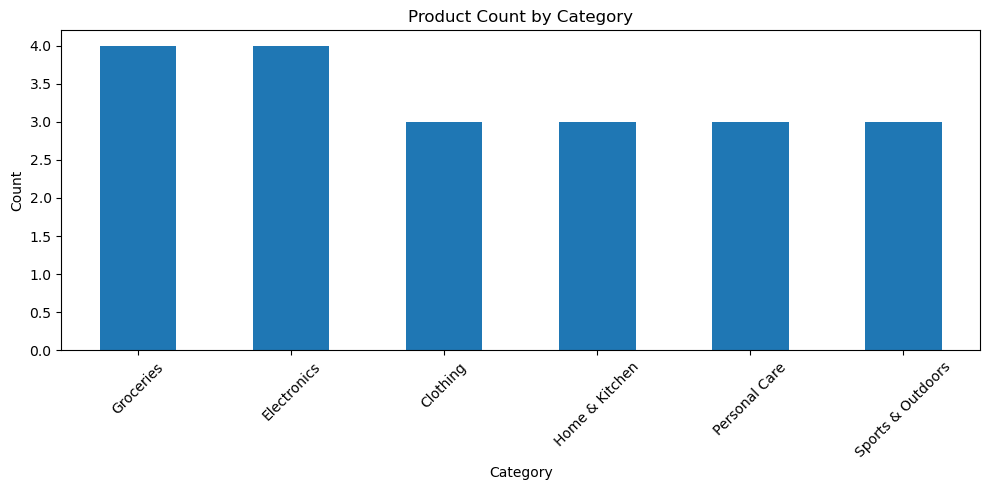

In [9]:
category_counts.plot(kind='bar', figsize=(10,5))
plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
#Brand Distribution

In [11]:
brand_counts = df['brand'].value_counts()
brand_counts

brand
FreshFarm    4
TechNova     4
UrbanWear    3
HomeEase     3
PureCare     3
ActivePro    3
Name: count, dtype: int64

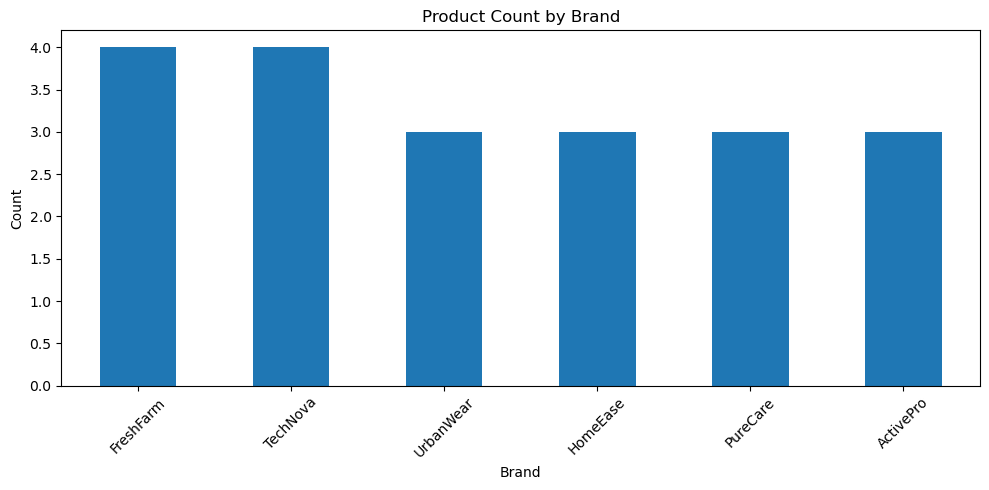

In [12]:
brand_counts.plot(kind='bar', figsize=(10,5))
plt.title("Product Count by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
#Price Analysis

In [16]:
print("Min Price:", df['price'].min())
print("Max Price:", df['price'].max())
print("Average Price:", round(df['price'].mean(), 2))

Min Price: 3.49
Max Price: 599.99
Average Price: 71.69


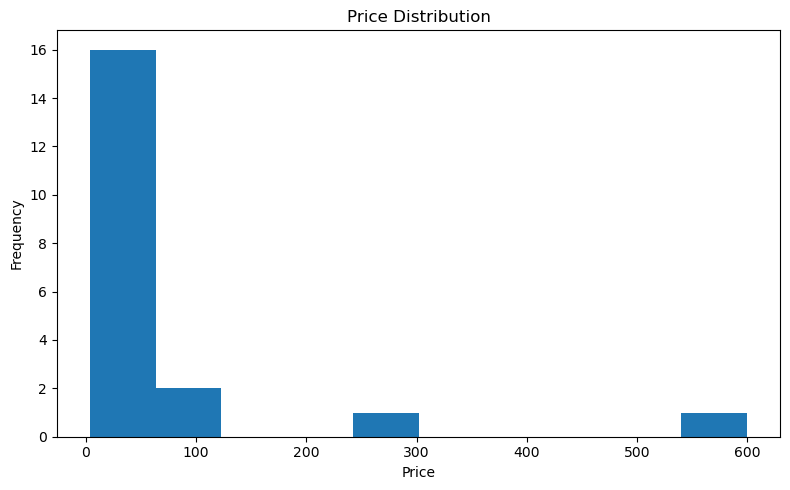

In [17]:
df['price'].plot(kind='hist', bins=10, figsize=(8,5))
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [18]:
#Rating Analysis

In [19]:
print("Min Rating:", df['rating'].min())
print("Max Rating:", df['rating'].max())
print("Average Rating:", round(df['rating'].mean(), 2))

Min Rating: 4.2
Max Rating: 4.6
Average Rating: 4.4


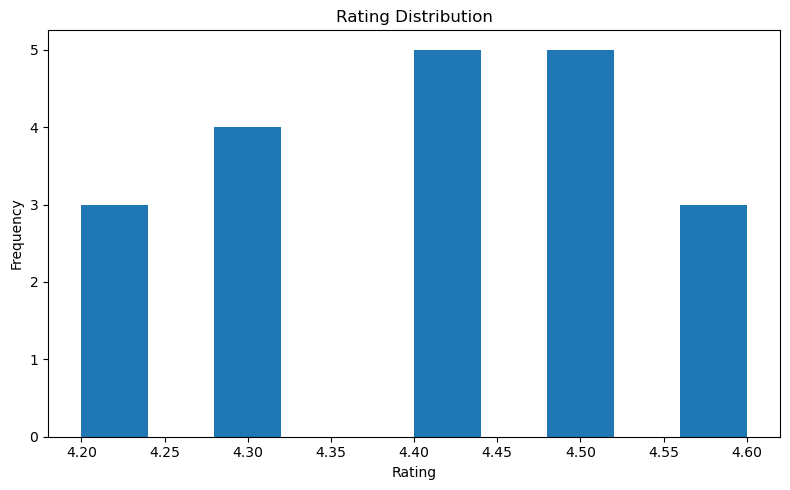

In [20]:
df['rating'].plot(kind='hist', bins=10, figsize=(8,5))
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [21]:
#Top Reviewed Products



In [23]:
df.sort_values(by='review_count', ascending=False)[
    ['product_name', 'brand', 'category', 'review_count', 'rating', 'price']
].head(10)

,product_name,brand,category,review_count,rating,price
0,Organic Whole Milk,FreshFarm,Groceries,320,4.6,4.99
7,Smart LED TV 40-inch,TechNova,Electronics,310,4.4,299.99
19,Laptop 14-inch,TechNova,Electronics,275,4.5,599.99
5,Running Shoes,ActivePro,Sports & Outdoors,260,4.6,79.99
15,Vacuum Cleaner,HomeEase,Home & Kitchen,220,4.3,89.99
17,Dumbbell Set,ActivePro,Sports & Outdoors,210,4.6,39.99
1,Bluetooth Wireless Headphones,TechNova,Electronics,210,4.4,59.99
8,Denim Jeans,UrbanWear,Clothing,200,4.3,29.99
13,Portable Power Bank,TechNova,Electronics,190,4.4,25.99
3,Non-Stick Cooking Pan,HomeEase,Home & Kitchen,180,4.5,24.99


In [24]:
#Average Price by Category

In [25]:
avg_price = df.groupby('category')['price'].mean().sort_values(ascending=False)
avg_price

category
Electronics          246.490000
Home & Kitchen        54.990000
Sports & Outdoors     46.656667
Clothing              25.990000
Personal Care         14.656667
Groceries              5.240000
Name: price, dtype: float64

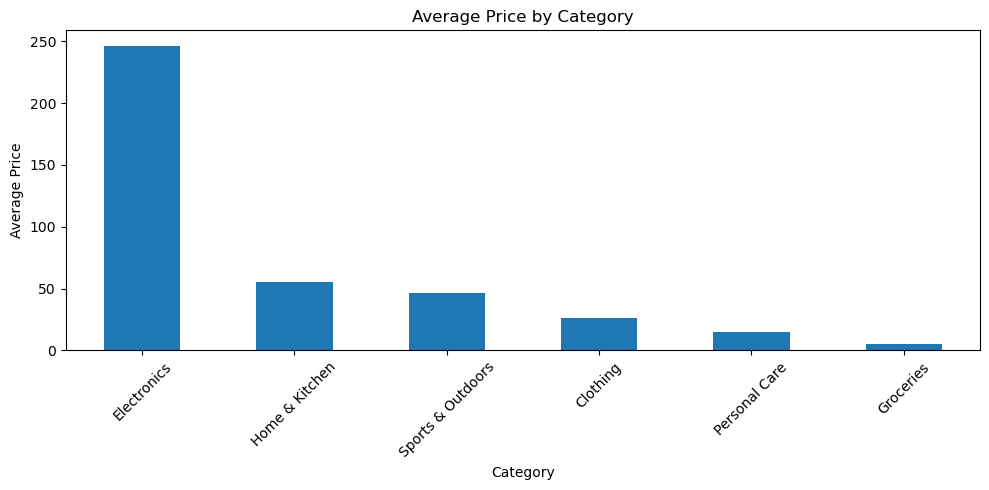

In [26]:
avg_price.plot(kind='bar', figsize=(10,5))
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
#Tag Analysis
tags = (
    df['tags']
    .fillna('')
    .str.split('|')
    .explode()
    .str.strip()
)

tags = tags[tags != '']
tags.value_counts().head(20)

tags
clothing       3
fitness        3
electronics    2
kitchen        2
healthy        2
snack          2
milk           1
hoodie         1
yoga           1
exercise       1
bread          1
bakery         1
battery        1
portable       1
charging       1
vacuum         1
warm           1
moisturizer    1
cleaning       1
home           1
Name: count, dtype: int64

In [ ]:
#Our product portfolio spans 6 categories with strong ratings across the board (avg 4.41⭐). 
#Electronics drives the highest revenue potential at $246 avg price, while Groceries drives the most customer engagement. 
#75% of our products are budget-priced — suggesting an opportunity to expand our mid-range offering to grow revenue per transaction.